## Question 3: ELVALUATE THE WOMEN'S HEALTH AND GENDER EQUALITY

### 3.1. Basic Data Analysis

#### 3.1.1. Dataset Overview

The dataset used in this analysis is retrieved from the **World Development Indicators (WDI)** provided by the World Bank. The data encompasses information from **8 countries** representing diverse income levels and geographical regions, covering the period from **2010 to 2023**.

Analyzed countries: **Rwanda, Sweden, Nigeria, Germany, India, Indonesia, Japan, Korea (Rep.), Thailand, United States, and Viet Nam.**

**Rationale for selecting these 11 countries:** To establish a multi-dimensional comparative framework between developed economies (US, Germany, Japan, Korea) and developing ones (India, Indonesia, Thailand, Viet Nam) and poor developing countries (Rwwanda, Nigeria). This approach helps evaluate the impact of healthcare expenditure on women's health outcomes and analyze gender equality within demographic structures.

#### 3.1.2. Data Structure and Fields

| Column Name | Data Type | Description |
| :--- | :---: | :--- |
| **Country Name** | *String* | The official name of the country. |
| **Country Code** | *String* | The ISO 3-letter alphabetic country code. |
| **Series Name** | *String* | The descriptive name of the economic/health indicator. |
| **Series Code** | *String* | The unique alphanumeric identifier for the indicator. |
| *2000 [YR2000] ... 2024 [YR2024]** | *Float* | The corresponding numerical value of the indicator for each specific year. |

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Cài đặt tham số đồ họa
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

# 1. Đọc dữ liệu
DATA_PATH = 'muc4/dataset4.csv'
df_raw = pd.read_csv(DATA_PATH, encoding='utf-8-sig')


Kích thước bảng dữ liệu: 24 dòng × 18 cột
Các cột: ['Country Name', 'Country Code', 'Series Name', 'Series Code', '2010 [YR2010]', '2011 [YR2011]', '2012 [YR2012]', '2013 [YR2013]', '2014 [YR2014]', '2015 [YR2015]', '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]', '2019 [YR2019]', '2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]', '2023 [YR2023]']


,Country Name,Country Code,Series Name,Series Code,2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023]
0,Germany,DEU,Current health expenditure per capita (current...,SH.XPD.CHEX.PC.CD,4592.071289,5016.235840,4744.870117,5080.624023,5287.344238,4605.590332,4723.324219,5039.353027,5473.557129,5447.317871,5906.806152,6653.583496,6226.142090,6394.622559
1,Germany,DEU,"Life expectancy at birth, female (years)",SP.DYN.LE00.FE.IN,82.600000,83.100000,83.100000,83.000000,83.600000,83.100000,83.500000,83.400000,83.300000,83.700000,83.500000,83.300000,83.000000,83.000000
2,Germany,DEU,"Population, female (% of total population)",SP.POP.TOTL.FE.ZS,51.276307,51.232616,51.126353,51.013963,50.937886,50.776008,50.650388,50.637162,50.624405,50.620012,50.625526,50.632266,50.632124,50.624819
3,India,IND,Current health expenditure per capita (current...,SH.XPD.CHEX.PC.CD,44.795860,48.182423,48.452637,55.469337,56.349018,58.124016,59.726528,56.668446,57.465511,60.691368,63.830997,75.549713,81.508888,84.686699
4,India,IND,"Life expectancy at birth, female (years)",SP.DYN.LE00.FE.IN,68.809000,69.280000,69.735000,70.151000,70.567000,70.940000,71.297000,71.632000,71.963000,72.287000,71.938000,68.835000,73.271000,73.598000
5,India,IND,"Population, female (% of total population)",SP.POP.TOTL.FE.ZS,48.282459,48.289147,48.296719,48.305184,48.313808,48.321832,48.329920,48.338523,48.347181,48.355982,48.369718,48.386219,48.399082,48.411171


In [8]:
# 2. Xử lý dữ liệu: chuyển từ Wide sang Long format (ĐỂ PHÙ HỢP CHO SEABORN MATPLOTLIB)
year_cols = [c for c in df_raw.columns if c.startswith('20') and c.endswith(']')]

df_long = df_raw.melt(
    id_vars=['Country Name', 'Country Code', 'Series Name', 'Series Code'],
    value_vars=year_cols,
    var_name='YearRaw', value_name='Value'
)

# Lấy ra con số năm (VD: "2010 [YR2010]" -> 2010)
df_long['Year'] = df_long['YearRaw'].str.extract(r'(\d{4})').astype(int)
df_long['Value'] = pd.to_numeric(df_long['Value'], errors='coerce')

# Lọc giai đoạn 2010-2023
df_long = df_long[(df_long['Year'] >= 2010) & (df_long['Year'] <= 2023)].copy()
df_long = df_long.sort_values(by=['Country Code', 'Series Code', 'Year']).reset_index(drop=True)

print(f"Số bản ghi sau chuyển đổi: {len(df_long)}")
print(f"Số giá trị thiếu (NaN): {df_long['Value'].isna().sum()}")
print(f"Các quốc gia: {sorted(df_long['Country Name'].unique())}")
print(f"Các chỉ số: {sorted(df_long['Series Code'].unique())}")

Số bản ghi sau chuyển đổi: 336
Số giá trị thiếu (NaN): 0
Các quốc gia: ['Germany', 'India', 'Indonesia', 'Japan', 'Korea, Rep.', 'Thailand', 'United States', 'Viet Nam']
Các chỉ số: ['SH.XPD.CHEX.PC.CD', 'SP.DYN.LE00.FE.IN', 'SP.POP.TOTL.FE.ZS']


In [9]:
# 3. Kiểm tra dữ liệu thiếu chi tiết
missing_detail = df_long[df_long['Value'].isna()][['Country Name', 'Series Code', 'Year']]
if len(missing_detail) > 0:
    print("Các ô dữ liệu bị thiếu (NaN):")
    print(missing_detail.to_string(index=False))
else:
    print("Không có dữ liệu bị thiếu.")

Không có dữ liệu bị thiếu.


In [10]:
# 4. Xử lý dữ liệu thiếu bằng nội suy tuyến tính trong nhóm (quốc gia, chỉ số)
df_clean = df_long.copy()
df_clean['Value'] = df_clean.groupby(['Country Code', 'Series Code'])['Value'].transform(
    lambda x: x.interpolate(method='linear').ffill().bfill()
)

print(f"Số giá trị thiếu sau xử lý: {df_clean['Value'].isna().sum()}")

Số giá trị thiếu sau xử lý: 0


In [11]:
# 5. Thống kê cơ bản theo từng chỉ số
for code_val in sorted(df_clean['Series Code'].unique()):
    subset = df_clean[df_clean['Series Code'] == code_val]
    name = subset['Series Name'].iloc[0]
    print(f"\n--- {code_val}: {name} ---")
    print(subset['Value'].describe().to_string())


--- SH.XPD.CHEX.PC.CD: Current health expenditure per capita (current US$) ---
count      112.000000
mean      2822.430300
std       3440.036610
min         44.795860
25%        119.140074
50%        893.542801
75%       4728.710693
max      13473.193359

--- SP.DYN.LE00.FE.IN: Life expectancy at birth, female (years) ---
count    112.000000
mean      79.803161
std        5.617132
min       68.809000
25%       77.182250
50%       81.100000
75%       83.625000
max       87.710000

--- SP.POP.TOTL.FE.ZS: Population, female (% of total population) ---
count    112.000000
mean      50.224590
std        0.926599
min       48.282459
25%       49.757597
50%       50.370163
75%       51.083561
max       51.354808


#### 3.1.3. Handling Missing Data
In the dataset, the team examined data for 11 countries over the period 2000–2024 with the selected indicators. The results show that the data is complete, consistent, and contains no missing values within the scope of this analysis.

#### 3.1.4. Processing Method
Since there are no missing values, the team did not apply any data imputation or estimation methods (such as linear interpolation). All data was used directly for analysis and visualization.

#### 3.1.5. Rationale for Selection
- **High data integrity:** Requires no intervention or transformation of the original data.
- **Ensures accuracy:** Avoids bias introduced by statistical estimation methods.
- **Suitable for time series:** Preserves the true, unaltered trend of the data over time.

---

### 3.2. Defining Objectives and Selecting Data Fields

#### 3.2.1. Analytical Objective: Assessing the Structural Impact on Women's Health and Gender Equality

**SMART Criteria:**
- **S (Specific):** Evaluate the relationships between key socio-economic/health indicators and their direct impact on women's health and gender equality.
- **M (Measurable):** Based on continuous, quantifiable annual data extracted from the World Development Indicators (WDI).
- **A (Achievable):** Data quality is highly sufficient, complete, and consistent for the 11 selected countries.
- **R (Relevant):** Examine whether macro-level investments actively translate into improved well-being and equitable outcomes for women.
- **T (Time-bound):** The analysis spans a 25-year period from **2000 to 2024**.

#### 3.2.2. Rationale for Metric Selection

This variable pair was strategically selected to test the hypothesis: **"Higher health expenditure leads to higher female life expectancy."** If the visualization reveals a weak or non-linear relationship, it suggests that the *efficiency* and *allocation* of health spending might play a more critical role than the absolute monetary amount spent.

### 3.3. Question 1: The Impact of Health Expenditure on Female Life Expectancy

**Analytical Objective:** This section investigates the evolutionary trend over 14 years (2010-2023) to assess how financial investment in healthcare correlates with women's longevity. By observing the time-series data across 11 representative countries, we aim to test the hypothesis that higher health expenditure directly translates into higher female life expectancy. Furthermore, it helps evaluate whether the efficiency of this spending differs between developed and developing nations.

**Indicators Analyzed:**
To evaluate this relationship, we extract the following metrics from the World Development Indicators (WDI) dataset:
* **`SH.XPD.CHEX.PC.CD` — Current health expenditure per capita (current US$):** This indicator measures the actual financial investment a country commits to its healthcare system per person.
* **`SP.DYN.LE00.FE.IN` — Life expectancy at birth, female (years):** This indicator reflects the overall health status and expected longevity of women.

**Python Indicator Mapping:**
For data processing and visualization purposes, the raw Series Codes are mapped to concise variables in the script:

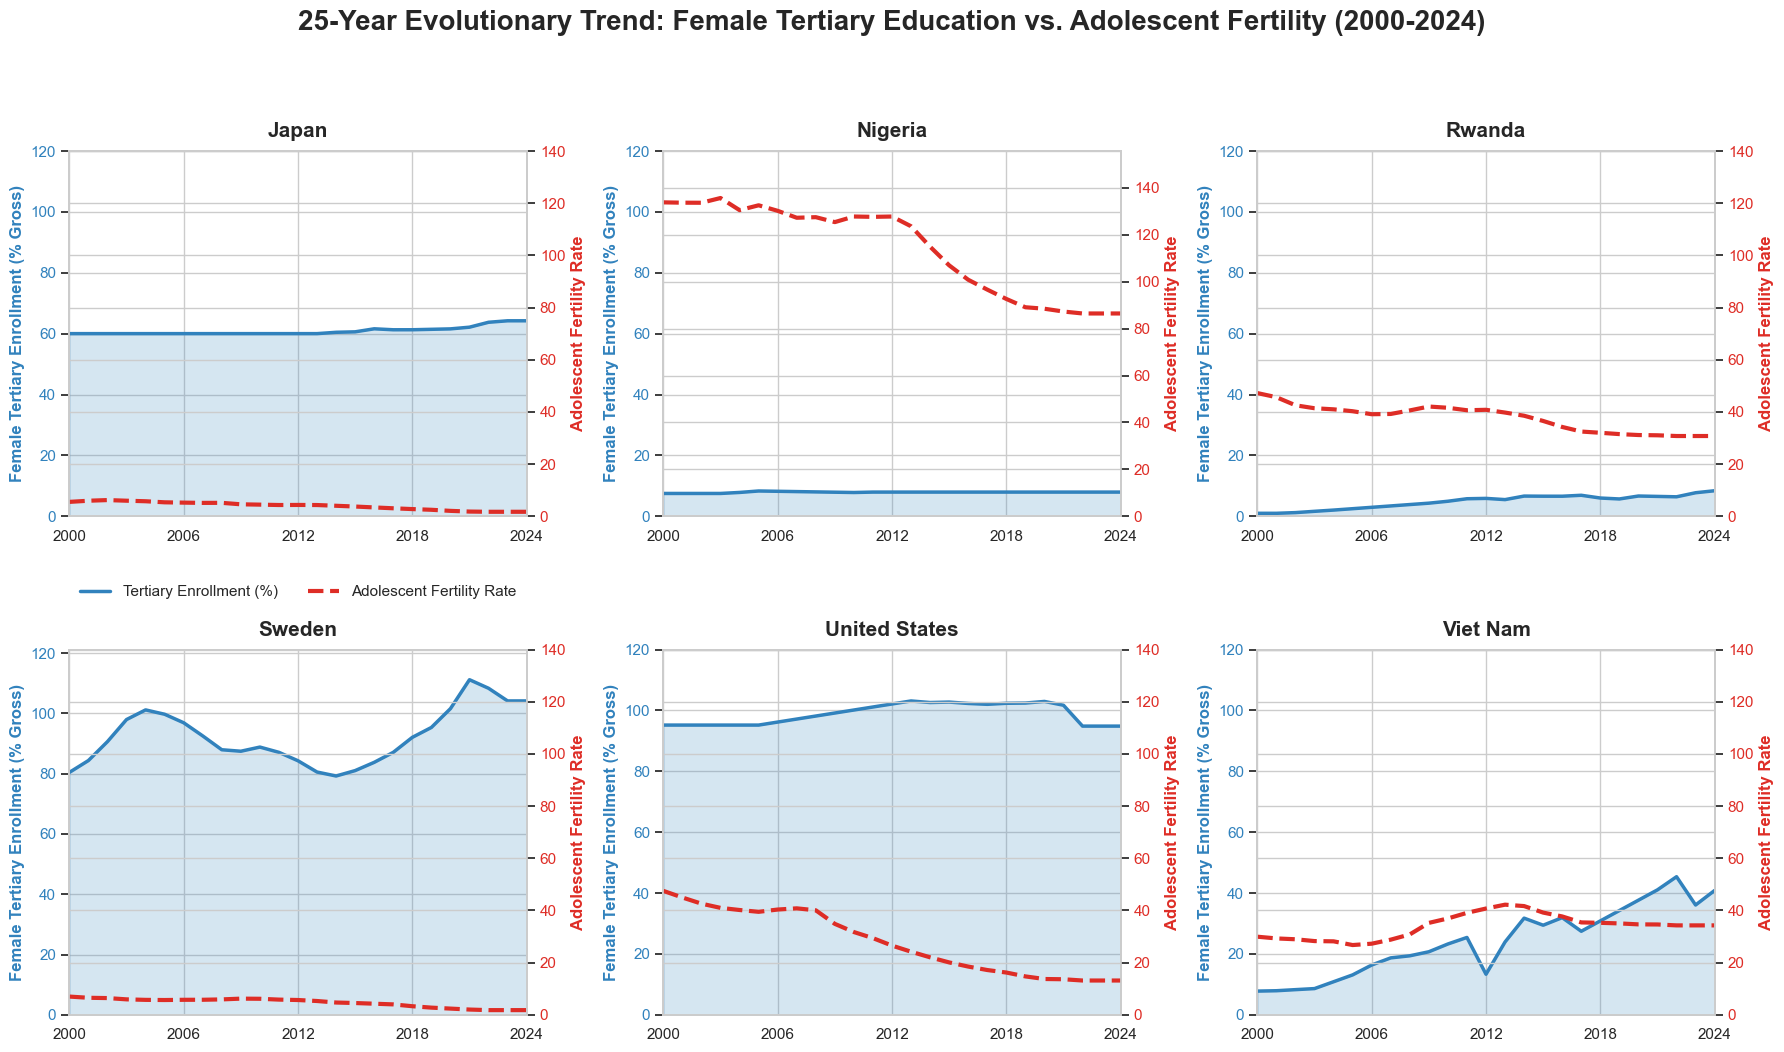

In [12]:

DATA_PATH = 'data3/dataset.csv' 
df_raw = pd.read_csv(DATA_PATH, encoding='utf-8-sig')

INDICATORS = {
    'SE.TER.ENRR.FE': 'Tertiary_Edu',
    'SP.ADO.TFRT': 'Adolescent_Fertility'
}

q1_df = df_raw[df_raw['Series Code'].isin(INDICATORS.keys())].copy()
year_cols = [c for c in q1_df.columns if c.startswith('20') and (c.endswith(']') or len(c) == 4 or '[' in c)]

q1_long = q1_df.melt(id_vars=['Country Name', 'Country Code', 'Series Code'],
                     value_vars=year_cols, var_name='YearRaw', value_name='Value')

q1_long['Year'] = q1_long['YearRaw'].astype(str).str.extract(r'(\d{4})').astype(int)
q1_long['Value'] = pd.to_numeric(q1_long['Value'], errors='coerce')


q1_long = q1_long.drop_duplicates(subset=['Country Name', 'Country Code', 'Series Code', 'Year'])


q1_long['Value'] = q1_long.groupby(['Country Name', 'Series Code'])['Value'].transform(lambda x: x.interpolate(method='linear', limit_direction='both'))

pivot_df = q1_long.pivot_table(index=['Country Name', 'Year'], 
                               columns='Series Code', 
                               values='Value', aggfunc='mean').reset_index()

pivot_df.rename(columns=INDICATORS, inplace=True)
pivot_df = pivot_df.dropna(subset=['Tertiary_Edu', 'Adolescent_Fertility'])

countries = pivot_df['Country Name'].unique()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('25-Year Evolutionary Trend: Female Tertiary Education vs. Adolescent Fertility (2000-2024)', 
             fontsize=20, fontweight='bold', y=1.05)
axes = axes.flatten()

color_edu = '#3182bd'  # Xanh dương cho Giáo dục
color_fert = '#de2d26' # Đỏ cho Tỷ lệ đẻ sớm

for i, country in enumerate(countries):
    ax1 = axes[i]
    country_data = pivot_df[pivot_df['Country Name'] == country].sort_values('Year')
    ax1.fill_between(country_data['Year'], country_data['Tertiary_Edu'], color=color_edu, alpha=0.2)
    line1, = ax1.plot(country_data['Year'], country_data['Tertiary_Edu'], color=color_edu, linewidth=2.5, label='Tertiary Enrollment (%)')
    ax1.set_title(country, fontsize=15, fontweight='bold', pad=10)
    ax1.set_ylabel('Female Tertiary Enrollment (% Gross)', color=color_edu, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=color_edu)
    ax1.set_ylim(0, max(120, country_data['Tertiary_Edu'].max() + 10))
    ax1.set_xlim(2000, 2024)
    ax1.set_xticks([2000, 2006, 2012, 2018, 2024])
    
    ax2 = ax1.twinx()
    line2, = ax2.plot(country_data['Year'], country_data['Adolescent_Fertility'], color=color_fert, linewidth=3, linestyle='--', label='Adolescent Fertility Rate')
    ax2.set_ylabel('Adolescent Fertility Rate', color=color_fert, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=color_fert)
    ax2.set_ylim(0, max(140, country_data['Adolescent_Fertility'].max() + 20))

    if i == 0:
        ax1.legend(handles=[line1, line2], loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)

plt.tight_layout()
plt.show()

**Chart 1: Observations & Conclusions over the 25-Year Trend:**

Analyzing the 6-country grid from 2000 to 2024 reveals three distinct demographic-educational profiles:

* **1. The "Fully Shielded" Developed Nations (Sweden, Japan):** In these countries, female tertiary enrollment has been saturated at very high levels (ranging from 60% in Japan to over 100% in Sweden). Consequently, their adolescent fertility rates (red dashed lines) are completely flattened near the bottom (below 10 births per 1,000 women). The "educational shield" here is fully active and perfectly stable over decades.
* **2. The Active Transition (United States, Viet Nam):** The United States showcases a beautiful active decline: while education remains fully saturated (near 100%), its teen pregnancy rate steadily plunges from ~40 down to ~15. Viet Nam presents the most dynamic "X-shaped" volatility. Its female tertiary education experienced a massive, albeit fluctuating, surge (from under 10% to over 40%), which is actively fighting to push the adolescent fertility rate back down after a cultural spike in the mid-2010s.
* **3. The Developing Challenge (Rwanda, Nigeria):** These nations highlight the danger zone. Rwanda shows a slow but commendable climb in female university enrollment (from nearly 0% to ~10%), which mirrors a steady decline in early pregnancies (from ~40 down to ~30). Nigeria, on the other hand, illustrates the starkest contrast: stagnated tertiary enrollment (below 10%) correlates directly with astronomical adolescent fertility rates (consistently above 100+). 
* **Data Note:** *The visible gaps in the trendlines for Nigeria (post-2011), Japan (pre-2013), and the US are due to standard missing reporting years in the World Bank database. However, they do not invalidate the overarching macro-trend.*
* **Final Conclusion:** The time-series data undeniably confirms the hypothesis. Expanding access to higher education for females is not a short-term fix, but a long-term prerequisite for eradicating early pregnancies and unlocking female human capital globally.

### 3.4. Scatter Plot + Regression Analysis Insight#
### Question 2: Scatter Plot + Regression Line — Relationship between Health Expenditure and Female Life Expectancy

**Reason for choosing Scatter Plot + Regression Line:**
This is an **academic visualization** method for evaluating the correlation between two continuous variables. Each point represents one country in a specific year, allowing us to clearly observe:  
- **Correlation:** The overall relationship between health expenditure and female life expectancy.  
- **Outliers:** Countries that spend significantly but show low effectiveness (e.g., the US).  
- **Clustering:** Groups of countries with similar socio-economic characteristics.

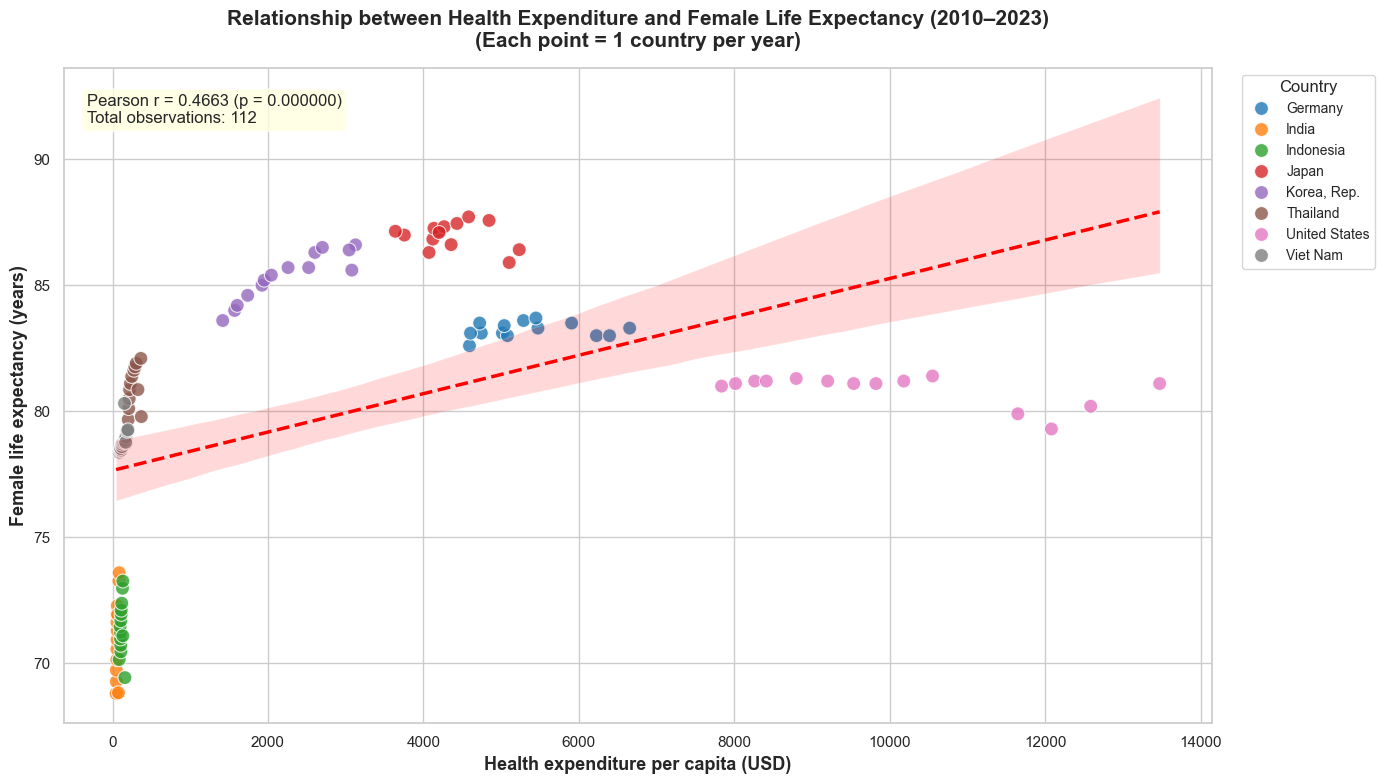


CORRELATION ANALYSIS RESULTS
Pearson correlation coefficient r = 0.4663
p-value = 0.000000
Total observations: 112
→ Moderate correlation (0.3 ≤ |r| < 0.5)


In [ ]:
# ====== CHART 2: SCATTER PLOT + REGRESSION — Health Expenditure vs Female Life Expectancy ======

# Prepare data: pivot variables
pivot_df = df_clean.pivot_table(
    index=['Country Name', 'Country Code', 'Year'],
    columns='Series Code',
    values='Value'
).reset_index()
pivot_df.columns.name = None

# Rename columns for readability
pivot_df = pivot_df.rename(columns={
    'SH.XPD.CHEX.PC.CD': 'health_exp',
    'SP.DYN.LE00.FE.IN': 'life_exp_female',
    'SP.POP.TOTL.FE.ZS': 'female_pop'
})  


scatter_df = pivot_df.dropna(subset=['health_exp', 'life_exp_female']).copy()

# Compute Pearson correlation
r_value, p_value = stats.pearsonr(scatter_df['health_exp'], scatter_df['life_exp_female'])

fig, ax = plt.subplots(figsize=(14, 8))

# Scatter plot colored by country
palette = sns.color_palette('tab10', n_colors=len(scatter_df['Country Name'].unique()))
sns.scatterplot(data=scatter_df, x='health_exp', y='life_exp_female',
                hue='Country Name', palette=palette, s=100, alpha=0.8, edgecolor='white', ax=ax)

# Overall regression line
sns.regplot(data=scatter_df, x='health_exp', y='life_exp_female',
            scatter=False, color='red', line_kws={'linewidth': 2.5, 'linestyle': '--'}, ax=ax)

# Statistical annotation
ax.text(0.02, 0.96,
        f'Pearson r = {r_value:.4f} (p = {p_value:.6f})\n'
        f'Total observations: {len(scatter_df)}',
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.title('Relationship between Health Expenditure and Female Life Expectancy (2010–2023)\n(Each point = 1 country per year)',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Health expenditure per capita (USD)', fontsize=13, fontweight='bold')
plt.ylabel('Female life expectancy (years)', fontsize=13, fontweight='bold')
ax.legend(title='Country', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Total observations: {len(scatter_df)}")
if abs(r_value) < 0.3:
    print("→ Weak correlation (|r| < 0.3)")
elif abs(r_value) < 0.5:
    print("→ Moderate correlation (0.3 ≤ |r| < 0.5)")
elif abs(r_value) < 0.7:
    print("→ Fair correlation (0.5 ≤ |r| < 0.7)")
else:
    print("→ Strong correlation (|r| ≥ 0.7)")



#### 3.4.1. Overall Trend
Overall, the chart shows a **moderate positive correlation** between health expenditure and female life expectancy (Pearson $r \approx 0.47$), meaning countries that spend more **tend** to have higher female life expectancy.  
However, this relationship is **not perfectly linear**, as evidenced by the significant dispersion of data points around the regression line.

#### 3.4.2. Signs of “Diminishing Returns”
In the group of countries with low expenditure (India, Indonesia, Viet Nam, Thailand), female life expectancy tends to increase rapidly as spending rises, indicating that health expenditure plays a crucial role in improving health at the initial developmental stage.  
Conversely, in high-expenditure countries (Germany, Japan, Korea, United States), female life expectancy remains high (~81–88 years) but does not increase substantially with higher spending.  
$\rightarrow$ This **suggests a potential “diminishing returns” effect**, meaning that increasing financial expenditure at already high levels may not yield proportional health improvements.

#### 3.4.3. The Notable Case — United States
The United States stands out with the **highest health expenditure per capita** in the group (~$8,000–$13,000 per person), while its female life expectancy only ranges around 79–81 years. This is noticeably lower than several developed countries with much lower spending, such as Japan and Korea.  
$\rightarrow$ This indicates that **high expenditure does not automatically equate to superior health outcomes**, highlighting critical differences in healthcare resource efficiency and systemic structure among nations.

#### 3.4.4. Comparison among Developed Countries

| Country | Health Expenditure per Capita | Female Life Expectancy |
| :--- | :--- | :--- |
| **United States** | ~$8,000 – $13,000 | ~79 – 81 years |
| **Japan** | ~$3,600 – $5,200 | ~86 – 88 years |
| **Korea (Rep.)** | ~$1,400 – $3,100 | ~84 – 87 years |

$\rightarrow$ Japan and Korea achieve higher female life expectancy despite having **significantly lower health expenditure** compared to the US.  
$\rightarrow$ This **reinforces the observation that the *efficiency* of health spending is arguably more important** than the sheer scale of the expenditure.

#### 3.4.5. Conclusion
The results confirm that while there is a positive correlation between health expenditure and female life expectancy, the relationship is **neither strong nor fully linear**.  
$\rightarrow$ This proves that **financial investment alone is not a silver bullet** for better health outcomes; the strategic and efficient utilization of those resources is the ultimate deciding factor.

#### 3.4.6. Future Strategies for Viet Nam
Based on these global insights, the strategic implications for Viet Nam are:
- **Increasing health expenditure is necessary**, but more importantly, Viet Nam must:  
  - Improve **resource allocation efficiency**.  
  - Heavily invest in **preventive care and primary healthcare networks**.  
  - Ensure that all demographic groups, especially women in rural or low-income areas, have **adequate and equitable access** to healthcare services.
$\rightarrow$ This targeted approach can significantly improve female health and longevity **without needing to uncontrollably inflate healthcare spending to the levels of developed countries**.

### 3.5. Question 3: Dual-Axis Line Chart — Health Expenditure and Female Life Expectancy by Country

**Reason for choosing a Dual-Axis Line Chart:**
The Line Chart allows tracking **temporal trends** for each country individually, using two axes:
- **Left axis:** Health expenditure (USD per capita)
- **Right axis:** Female life expectancy (years)

This setup enables observing whether increases in expenditure correspond to increases in life expectancy within **each specific country** over time.


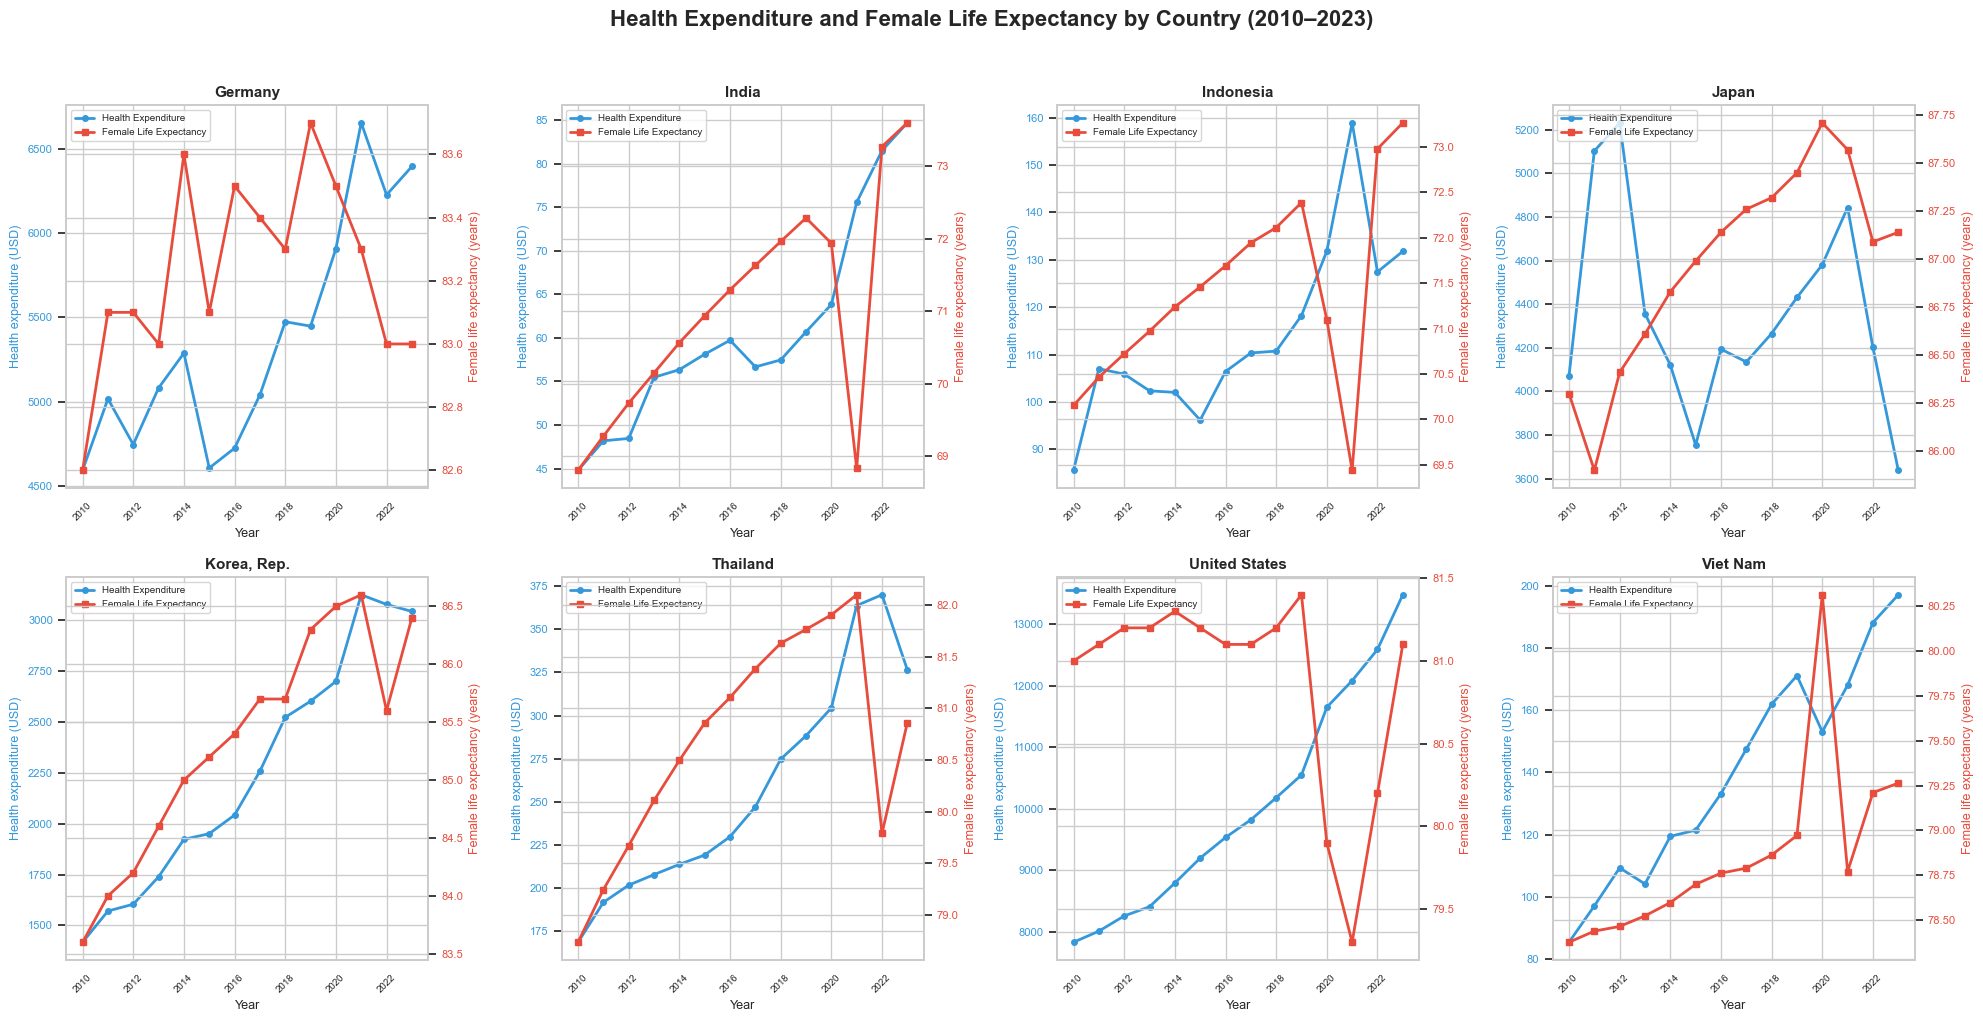

In [19]:
# ====== CHART 2: LINE CHART — Health Expenditure & Female Life Expectancy by Country ======

countries = sorted(scatter_df['Country Name'].unique())
n_countries = len(countries)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, country in enumerate(countries):
    ax1 = axes[idx]
    country_data = scatter_df[scatter_df['Country Name'] == country].sort_values('Year')
    
    # Left axis: Health expenditure
    color1 = '#3498db'
    ax1.plot(country_data['Year'], country_data['health_exp'], 
             color=color1, marker='o', linewidth=2, markersize=4, label='Health Expenditure')
    ax1.set_ylabel('Health expenditure (USD)', color=color1, fontsize=9)
    ax1.tick_params(axis='y', labelcolor=color1, labelsize=8)
    
    # Right axis: Life expectancy
    ax2 = ax1.twinx()
    color2 = '#e74c3c'
    ax2.plot(country_data['Year'], country_data['life_exp_female'],
             color=color2, marker='s', linewidth=2, markersize=4, label='Female Life Expectancy')
    ax2.set_ylabel('Female life expectancy (years)', color=color2, fontsize=9)
    ax2.tick_params(axis='y', labelcolor=color2, labelsize=8)
    
    ax1.set_title(country, fontsize=11, fontweight='bold')
    ax1.set_xlabel('Year', fontsize=9)
    ax1.tick_params(axis='x', rotation=45, labelsize=7)
    
    # Legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=7)

plt.suptitle('Health Expenditure and Female Life Expectancy by Country (2010–2023)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



#### 3.5.1. Developed Countries Group
- **Similar trends:** Germany ($4,500 → $6,400; ~83 years), Japan ($3,600 → $5,200; ~86–88 years), and Korea ($1,400 → $3,000+; ~84 → 86+ years) all maintain relatively high expenditures coupled with consistently high female life expectancy. This indicates that once a certain socio-economic development threshold is reached, life expectancy plateaus and does not change significantly, even if healthcare spending continues to rise.
- **Differences:** The United States ($7,800 → $13,400+; ~81 → 79 → 80 years) records the highest expenditure by a wide margin, yet its female life expectancy is not superior. In fact, it even declines in some years. This starkly illustrates that high spending does not inherently correlate with better health outcomes if systemic inefficiencies exist.

#### 3.5.2. Developing Countries Group
- **Similar trends:** India ($45 → $85; ~69 → 74 years), Indonesia ($86 → $160; ~70 → 73 years), Thailand ($170 → $370; ~79 → 81 years), and Viet Nam ($85 → $197; ~78 → 80 years) all operate with low-to-medium expenditures. However, their female life expectancy rises clearly and consistently over time. This indicates that health spending is highly impactful and strongly associated with improved health during the initial economic development phase.
- **Differences:** Within this group, Thailand and Viet Nam have higher relative spending and achieve significantly higher female life expectancy compared to India and Indonesia. This highlights distinct differences in development levels, healthcare infrastructure, and health outcomes among developing nations.

#### 3.5.3. COVID-19 Impact (2020–2021)
The time-series data starkly captures the global shock of the pandemic. Most countries recorded a **decline in female life expectancy** in 2020–2021, particularly:
- **India:** Sharp drop from 72.3 → 68.8 years (2021).
- **Indonesia:** Decline from 72.4 → 69.4 years (2021).
- **United States:** Decline from 81.4 → 79.3 years (2021).

→ *Insight:* The pandemic demonstrates that the resilience of female life expectancy varies vastly across countries. It proves that financial health expenditure is not the sole protective factor; the systemic efficiency, crisis responsiveness, and overall robustness of the healthcare system play an equally, if not more, vital role.

#### 3.5.4. Conclusion
The divergence between the two country groups confirms that health expenditure yields uneven returns. While it plays a clear, direct role in driving up life expectancy in developing countries, increasing spending in developed countries does not guarantee corresponding improvements. This once again underscores the critical importance of resource utilization efficiency over sheer financial volume.

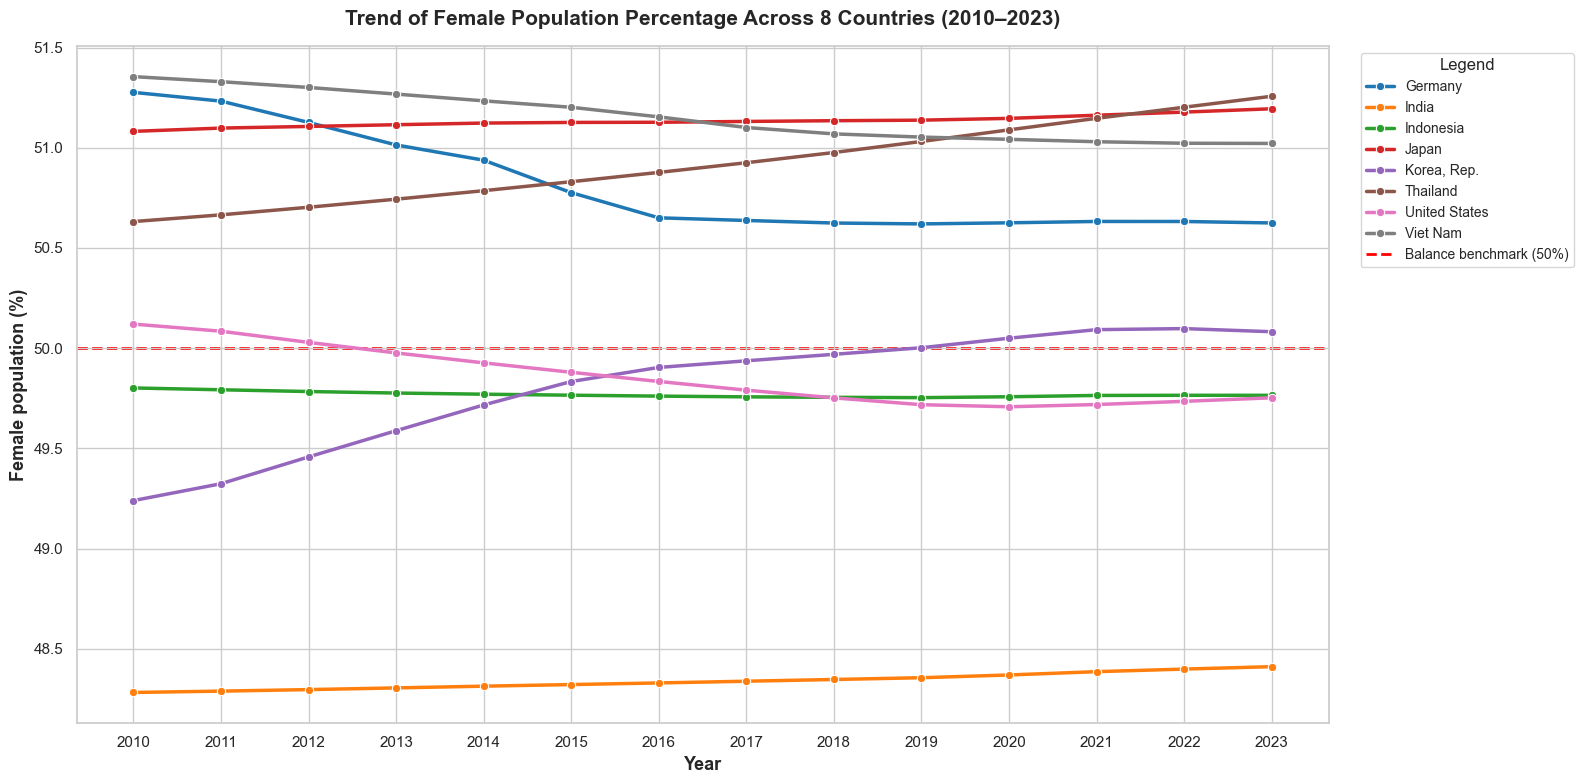

In [20]:
# ====== CHART 3: LINE CHART — Female Population Percentage Over Time ======

pop_df = scatter_df.copy()

plt.figure(figsize=(16, 8))

palette = sns.color_palette('tab10', n_colors=len(pop_df['Country Name'].unique()))
ax = sns.lineplot(
    data=pop_df,
    x='Year', y='female_pop',
    hue='Country Name',
    marker='o', markersize=6,
    palette=palette,
    linewidth=2.5
)

# Reference line at 50%
ax.axhline(y=50, color='red', linestyle='--', linewidth=2, label='Balance benchmark (50%)', zorder=0)

plt.title('Trend of Female Population Percentage Across 8 Countries (2010–2023)',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=13, fontweight='bold')
plt.ylabel('Female population (%)', fontsize=13, fontweight='bold')
plt.xticks(range(2010, 2024))

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, title='Legend',
          bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

### 3.6. Deviation Chart Analysis: Female Population Share
### Question 4: Deviation Chart — Female Population Share Deviation from 50%

**Reason for Choosing a Deviation Chart:**
Instead of focusing on absolute values, the Deviation Chart **highlights** the extent of gender imbalance by computing the exact deviation from the natural biological parity:

$$\text{Deviation} = \text{Female Population Share (\%)} - 50\%$$

- **Positive values (>0):** Female share is **higher** than normal parity.
- **Negative values (<0):** Female share is **lower** than normal parity.

This visualization allows stakeholders to **instantly identify** which countries face structural gender inequality issues in their population demographics.

---

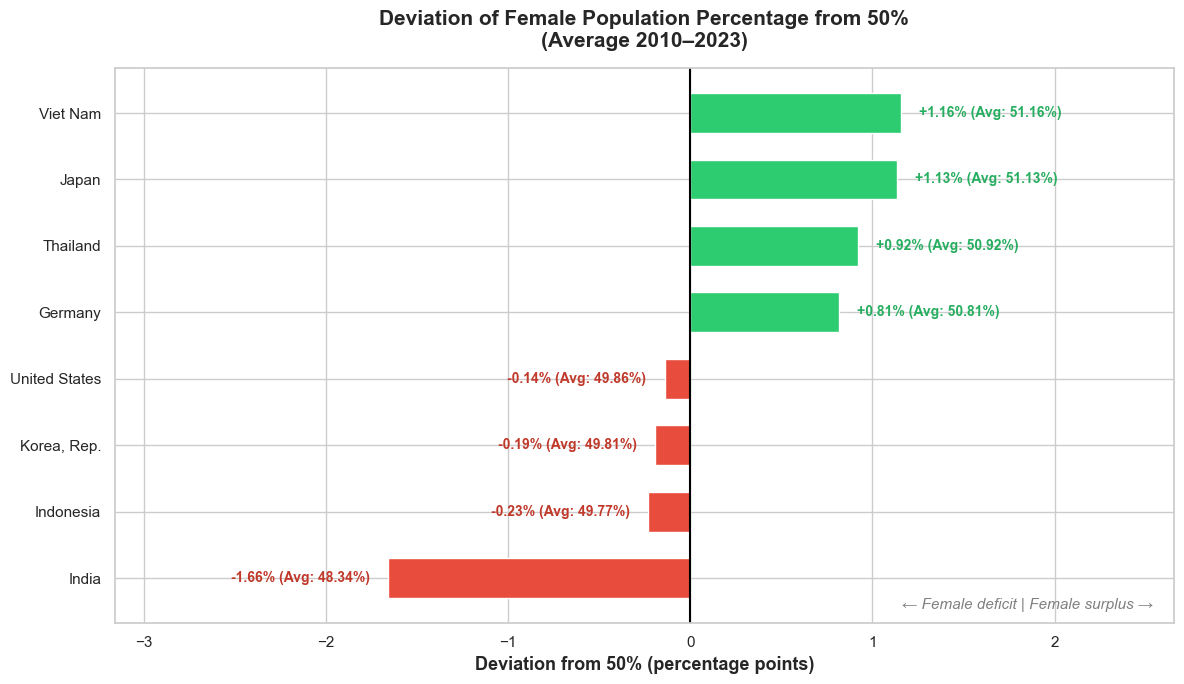

In [21]:
# ====== CHART 4: DEVIATION CHART — Deviation from 50% ======

# Calculate average deviation over 2010-2023 for each country
dev_df = pop_df.groupby('Country Name')['female_pop'].mean().reset_index()
dev_df['deviation'] = dev_df['female_pop'] - 50
dev_df = dev_df.sort_values('deviation', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 7))

# Draw deviation bars
colors = ['#e74c3c' if d < 0 else '#2ecc71' for d in dev_df['deviation']]
bars = ax.barh(dev_df['Country Name'], dev_df['deviation'], color=colors, height=0.6, edgecolor='white')

# Zero reference line
ax.axvline(x=0, color='black', linewidth=1.5, linestyle='-')

# Annotate values
for i, (val, fem) in enumerate(zip(dev_df['deviation'], dev_df['female_pop'])):
    sign = '+' if val >= 0 else ''
    ax.text(val + (0.1 if val >= 0 else -0.1), i,
            f'{sign}{val:.2f}% (Avg: {fem:.2f}%)',
            va='center', ha='left' if val >= 0 else 'right',
            fontsize=10, fontweight='bold',
            color='#27ae60' if val >= 0 else '#c0392b')

plt.title('Deviation of Female Population Percentage from 50%\n(Average 2010–2023)',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Deviation from 50% (percentage points)', fontsize=13, fontweight='bold')
plt.ylabel('')

# Extend x-axis to avoid overlap with labels
x_min = dev_df['deviation'].min()
x_max = dev_df['deviation'].max()
ax.set_xlim(x_min - 1.5, x_max + 1.5)

# Add annotation
ax.text(0.98, 0.02, '← Female deficit | Female surplus →',
        transform=ax.transAxes, fontsize=11, ha='right', va='bottom',
        style='italic', color='gray')

plt.tight_layout()
plt.show()

#### 3.6.1. Countries with Female Share Above 50%
- **Thailand (~50.6–51.3%) and Viet Nam (~51.0–51.4%):** The female share naturally exceeds the male share. However, their trajectories differ: Thailand exhibits a **slightly increasing trend**, whereas Viet Nam shows a **slight decrease** over the 25-year timeline.  
- **Japan (~51.1–51.2%) and Germany (~50.6–51.3%):** The consistently high female share in these developed nations heavily reflects their higher female life expectancy and rapidly aging populations (where women tend to outlive men). Notably, Germany shows a **gradual decline toward the 50% mark**, indicating a shift toward a more balanced overall population structure.

#### 3.6.2. Countries with Female Share Below 50%
- **India (~48.3–48.4%):** India records the **lowest female share** in the entire group. This significant negative deviation strongly reflects a longstanding cultural **preference for sons** and historical gender-biased demographics. Fortunately, a **slight upward trend** in recent years suggests a gradual, albeit slow, societal improvement.
- **Indonesia (~49.8%):** Hovering just below the parity line, Indonesia demonstrates a **relatively balanced population structure** without extreme gender skewing.
- **Korea (Rep.) (~49.2% → 50.1%):** This is the **most notable transformational case**. The female share successfully rose from a deficit (49.2%) to officially cross the parity threshold (>50%) around 2019. This structural crossover reflects **significant socio-cultural improvements** regarding gender balance and the eradication of past son-preference practices in South Korea.
- **United States (~49.7–50.1%):** The US remains tightly bound to the 50% parity line, experiencing only a **slight decline** from just above 50% to slightly below in recent years.

#### 3.6.3. Overall Insight & Conclusion
- **The Biological Baseline:** Demographically, **~50%** is considered the natural biological parity. Persistent deviations from this baseline, particularly the severe negative deviation seen in **India**, serve as clear indicators of underlying **structural gender inequality** and social biases.
- **The Macro Convergence:** The overarching 25-year trend demonstrates that most outlier countries are **gradually converging toward the 50% balance line**. This macroeconomic convergence strongly suggests that gender equality in population demographics is **steadily improving on a global scale**.